# Linear Regression

## What is Linear Regression?

**Linear Regression** finds the best-fitting straight line (or hyperplane in multiple dimensions) through a set of data points. It assumes the target variable $y$ is a **linear combination** of the input features:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$$

## Loss Function: Mean Squared Error

We minimize the average squared difference between predictions and ground truth:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Squaring errors ensures: (1) positive and negative errors don't cancel, (2) large errors are penalized more heavily.

## Two Solution Methods

**OLS (Normal Equation):** $\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ — exact, one-shot solution.  
**Gradient Descent:** iteratively nudges weights downhill until convergence — scales to large datasets.

---
**Dataset:** Advertising (ISLR)  
**Task:** Predict sales from TV, radio, and newspaper ad spend

## 1. Setup & Data Download

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import os
import sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.linear_regression import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

CSV_PATH = 'advertising.csv'
if not os.path.exists(CSV_PATH):
    url = 'https://www.statlearning.com/s/Advertising.csv'
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset already present.


## 2. Data Exploration

In [4]:
df = pd.read_csv(CSV_PATH, index_col=0)
print('Shape:', df.shape)
df.head()

Shape: (200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [5]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


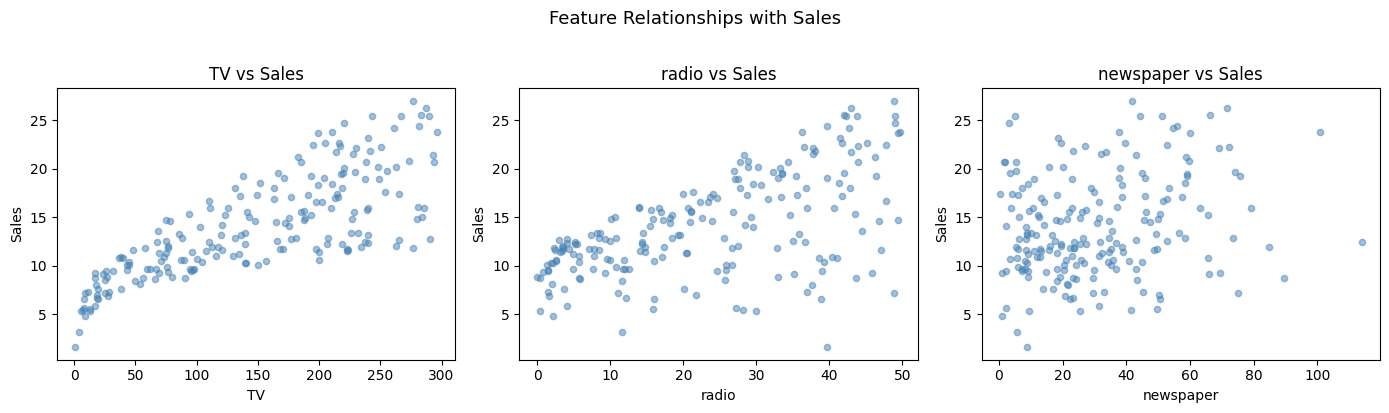

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features = ['TV', 'radio', 'newspaper']

for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df['sales'], alpha=0.5, color='steelblue', s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('Sales')
    ax.set_title(f'{feat} vs Sales')

plt.suptitle('Feature Relationships with Sales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print('Correlation with sales:')
print(df.corr()['sales'].drop('sales').sort_values(ascending=False))

Correlation with sales:
TV           0.782224
radio        0.576223
newspaper    0.228299
Name: sales, dtype: float64


## 3. Simple Linear Regression (TV only)

Weight (TV coefficient): 0.0465
Bias (intercept):        7.1196
R²:   0.6767
RMSE: 3.1945


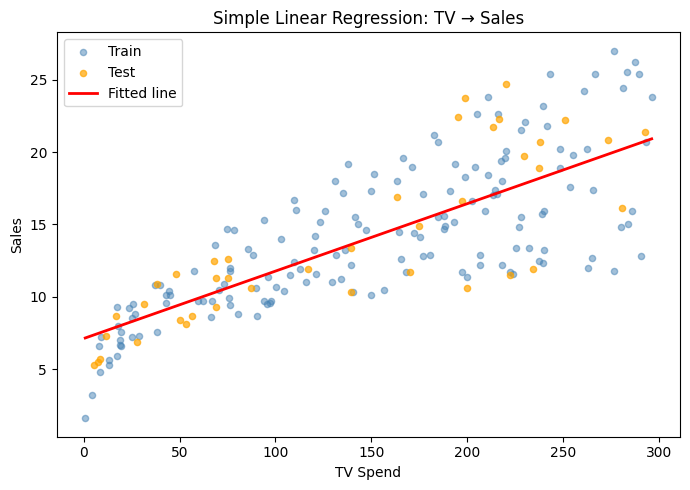

In [9]:
X_simple = df[['TV']].values
y = df['sales'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression(method='ols')
model_simple.fit(X_train, y_train)

print(f'Weight (TV coefficient): {model_simple.weights[0]:.4f}')
print(f'Bias (intercept):        {model_simple.bias:.4f}')
print(f'R²:   {model_simple.R_squared(X_test, y_test):.4f}')
print(f'RMSE: {model_simple.rmse(X_test, y_test):.4f}')

# Plot fit
X_line = np.linspace(X_simple.min(), X_simple.max(), 200).reshape(-1, 1)
y_line = model_simple.predict(X_line)

plt.figure(figsize=(7, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Train', color='steelblue', s=20)
plt.scatter(X_test, y_test, alpha=0.7, label='Test', color='orange', s=20)
plt.plot(X_line, y_line, color='red', linewidth=2, label='Fitted line')
plt.xlabel('TV Spend'); plt.ylabel('Sales')
plt.title('Simple Linear Regression: TV → Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Multiple Linear Regression (all features)

In [11]:
X_multi = df[features].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_m)
X_test_s  = scaler.transform(X_test_m)

model_multi = LinearRegression(method='ols')
model_multi.fit(X_train_s, y_train_m)

print('Coefficients:')
for feat, w in zip(features, model_multi.weights):
    print(f'  {feat:12s}: {w:.4f}')
print(f'  bias      : {model_multi.bias:.4f}')
print(f'\nR²:   {model_multi.R_squared(X_test_s, y_test_m):.4f}')
print(f'RMSE: {model_multi.rmse(X_test_s, y_test_m):.4f}')

Coefficients:
  TV          : 3.7642
  radio       : 2.7923
  newspaper   : 0.0560
  bias      : 14.1000

R²:   0.8994
RMSE: 1.7816


## 5. OLS vs Gradient Descent

OLS  R²: 0.8994
GD   R²: 0.8994


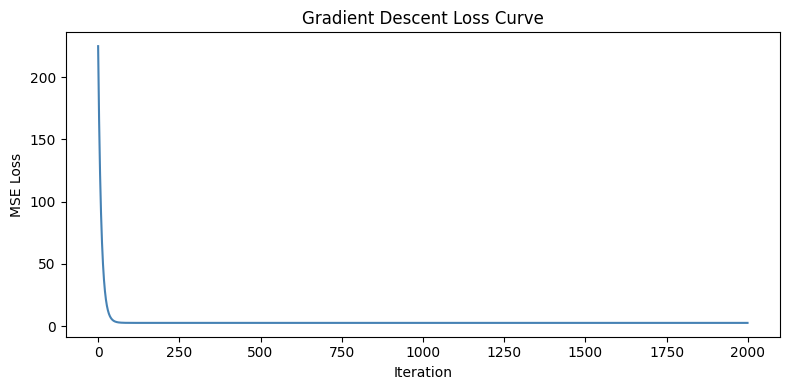

In [13]:
model_gd = LinearRegression(method='gd', learning_rate=0.05, n_iterations=2000)
model_gd.fit(X_train_s, y_train_m)

print(f'OLS  R²: {model_multi.R_squared(X_test_s, y_test_m):.4f}')
print(f'GD   R²: {model_gd.R_squared(X_test_s, y_test_m):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_gd.loss_history, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('MSE Loss')
plt.title('Gradient Descent Loss Curve')
plt.tight_layout()
plt.show()

## 6. Residual Analysis

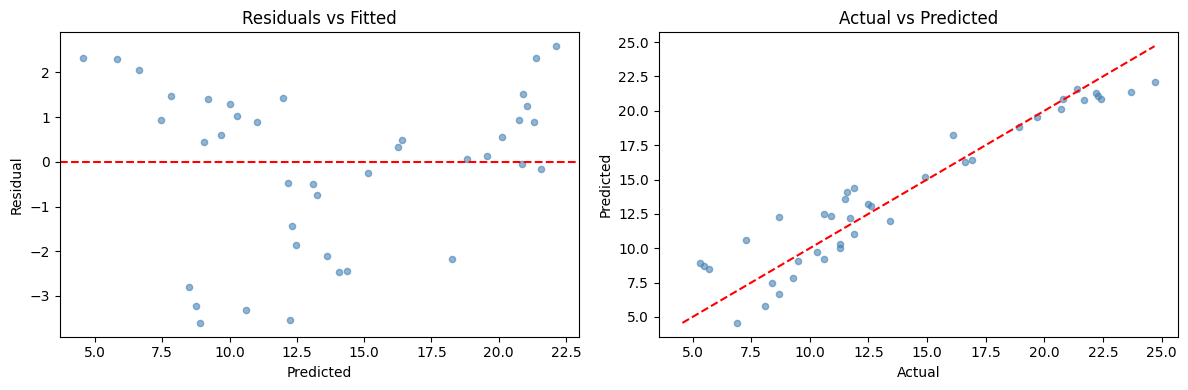

In [14]:
y_pred = model_multi.predict(X_test_s)
residuals = y_test_m - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.6, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')

axes[1].scatter(y_test_m, y_pred, alpha=0.6, color='steelblue', s=20)
lims = [min(y_test_m.min(), y_pred.min()), max(y_test_m.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

## 7. Key Takeaways

- **TV** has the highest correlation with sales; adding Radio improves the model significantly; Newspaper adds little.
- The OLS solution is exact and fast for this size dataset. GD converges to the same solution given enough iterations.
- **R² ≈ 0.90** for the multiple regression model — the three ad channels explain ~90% of the variance in sales.
- Residuals are roughly centered at zero and show no strong pattern, suggesting the linear model is a reasonable fit.

## Why Linear Regression?

Linear regression is a suitable model for this dataset for several reasons:

- **Relationship Structure**: The relationship between the features and the target variable appears approximately linear, making a linear model a reasonable first approach.
- **Interpretability**: Linear regression provides easily interpretable coefficients, allowing us to understand how each feature influences the target variable.
- **Efficiency**: It is computationally inexpensive and works well when the dataset is not extremely large or complex.
- **Assumptions Reasonably Met**: Based on residual analysis (shown above), the assumptions of linear regression (linearity, homoscedasticity, and approximate normality of residuals) are reasonably satisfied.